In [50]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

from xgboost import XGBClassifier
import xgboost as xgb

In [51]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname)

/kaggle/input
/kaggle/input/datasets
/kaggle/input/datasets/sartajbhuvaji
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Training/glioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/no_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/pituitary_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Testing/meningioma_tumor
/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri/Test

In [52]:
import os
import numpy as np
import pandas as pd
import pathlib
import imageio
from glob import glob

In [53]:
from glob import glob

base_dir = "/kaggle/input/datasets/sartajbhuvaji/brain-tumor-classification-mri"

glioma = glob(base_dir + "/Training/glioma_tumor/*")
meningioma = glob(base_dir + "/Training/meningioma_tumor/*")
no_tumor = glob(base_dir + "/Training/no_tumor/*")
pituitary = glob(base_dir + "/Training/pituitary_tumor/*")

print("Glioma Images:", len(glioma))
print("Meningioma Images:", len(meningioma))
print("No Tumor Images:", len(no_tumor))
print("Pituitary Images:", len(pituitary))
print("\nTotal Images:",len(glioma + meningioma + no_tumor + pituitary))

Glioma Images: 826
Meningioma Images: 822
No Tumor Images: 395
Pituitary Images: 827

Total Images: 2870


In [54]:
import random

#20% train
# Glioma
glioma_train = glioma[:660]
glioma_test  = glioma[660:784]
glioma_val   = glioma[784:826]

# Meningioma
meningioma_train = meningioma[:657]
meningioma_test  = meningioma[657:781]
meningioma_val   = meningioma[781:822]

# No Tumor
no_train = no_tumor[:316]
no_test  = no_tumor[316:375]
no_val   = no_tumor[375:395]

# Pituitary
pituitary_train = pituitary[:661]
pituitary_test  = pituitary[661:785]
pituitary_val   = pituitary[785:827]

train_imgs = ( glioma_train + meningioma_train + no_train + pituitary_train)
test_imgs = ( glioma_test + meningioma_test +no_test + pituitary_test)
val_imgs = (glioma_val +meningioma_val +no_val +pituitary_val)

print("Total Train Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % (len(train_imgs),len(glioma_train),len(meningioma_train),len(no_train),len(pituitary_train)))

print("Total Test Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % ( len(test_imgs), len(glioma_test), len(meningioma_test), len(no_test), len(pituitary_test)))

print("Total Validation Images %s containing %s glioma, %s meningioma, %s no_tumor and %s pituitary images"
    % (len(val_imgs),len(glioma_val),len(meningioma_val),len(no_val),len(pituitary_val)))

random.seed(42)
random.shuffle(glioma)
random.shuffle(meningioma)
random.shuffle(no_tumor)
random.shuffle(pituitary)

Total Train Images 2294 containing 660 glioma, 657 meningioma, 316 no_tumor and 661 pituitary images
Total Test Images 431 containing 124 glioma, 124 meningioma, 59 no_tumor and 124 pituitary images
Total Validation Images 145 containing 42 glioma, 41 meningioma, 20 no_tumor and 42 pituitary images


In [55]:
def preprocess_image(image_list):
    X = []
    y = []

    for image in image_list:

        try:
            img = cv2.imread(image, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (128,128))

            img = img.astype(np.float32) / 255.0

            X.append(img)

        except:
            continue

        if 'glioma_tumor' in image:
            y.append(0)

        elif 'meningioma_tumor' in image:
            y.append(1)

        elif 'no_tumor' in image:
            y.append(2)

        elif 'pituitary_tumor' in image:
            y.append(3)

    return np.array(X), np.array(y)

In [56]:
X_train, y_train = preprocess_image(train_imgs)
X_test, y_test = preprocess_image(test_imgs)
X_val, y_val = preprocess_image(val_imgs)

print(X_train.shape)
print(X_test.shape)
print(X_val.shape)

(2294, 128, 128)
(431, 128, 128)
(145, 128, 128)


In [57]:
X_train = X_train.reshape(X_train.shape[0], -1)
X_test  = X_test.reshape(X_test.shape[0], -1)
X_val   = X_val.reshape(X_val.shape[0], -1)

In [58]:
xgb_params = {
    'objective': 'multi:softmax',
    'num_class': 4,
    'max_depth': 6,
    'learning_rate': 0.1,
    'n_estimators': 200,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'random_state': 42,
    'eval_metric': 'mlogloss',
    'verbosity': 1
}

xgb_model = XGBClassifier(**xgb_params)

xgb_model.fit(
    X_train,
    y_train,
    eval_set=[(X_val, y_val)],
    verbose=True
)

[0]	validation_0-mlogloss:1.23482
[1]	validation_0-mlogloss:1.13619
[2]	validation_0-mlogloss:1.06059
[3]	validation_0-mlogloss:0.99017
[4]	validation_0-mlogloss:0.92377
[5]	validation_0-mlogloss:0.86456
[6]	validation_0-mlogloss:0.81195
[7]	validation_0-mlogloss:0.76918
[8]	validation_0-mlogloss:0.72643
[9]	validation_0-mlogloss:0.68948
[10]	validation_0-mlogloss:0.65550
[11]	validation_0-mlogloss:0.62674
[12]	validation_0-mlogloss:0.59855
[13]	validation_0-mlogloss:0.57759
[14]	validation_0-mlogloss:0.55303
[15]	validation_0-mlogloss:0.53405
[16]	validation_0-mlogloss:0.51177
[17]	validation_0-mlogloss:0.49610
[18]	validation_0-mlogloss:0.47953
[19]	validation_0-mlogloss:0.46594
[20]	validation_0-mlogloss:0.45467
[21]	validation_0-mlogloss:0.44214
[22]	validation_0-mlogloss:0.42890
[23]	validation_0-mlogloss:0.41829
[24]	validation_0-mlogloss:0.40644
[25]	validation_0-mlogloss:0.39733
[26]	validation_0-mlogloss:0.39075
[27]	validation_0-mlogloss:0.38441
[28]	validation_0-mlogloss:0.3

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=None, num_class=4, ...)

In [59]:
y_pred = xgb_model.predict(X_test)

In [60]:
from sklearn.metrics import accuracy_score

# Training accuracy
y_train_pred = xgb_model.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Validation accuracy
y_val_pred = xgb_model.predict(X_val)
val_accuracy = accuracy_score(y_val, y_val_pred)

# Test accuracy
y_test_pred = xgb_model.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training Accuracy   : {train_accuracy*100:.2f}%")
print(f"Validation Accuracy : {val_accuracy*100:.2f}%")
print(f"Test Accuracy       : {test_accuracy*100:.2f}%")

Training Accuracy   : 100.00%
Validation Accuracy : 91.72%
Test Accuracy       : 93.97%


              precision    recall  f1-score   support

      glioma       0.97      0.94      0.96       124
  meningioma       0.92      0.90      0.91       124
    no_tumor       0.90      0.93      0.92        59
   pituitary       0.95      0.98      0.96       124

    accuracy                           0.94       431
   macro avg       0.93      0.94      0.94       431
weighted avg       0.94      0.94      0.94       431



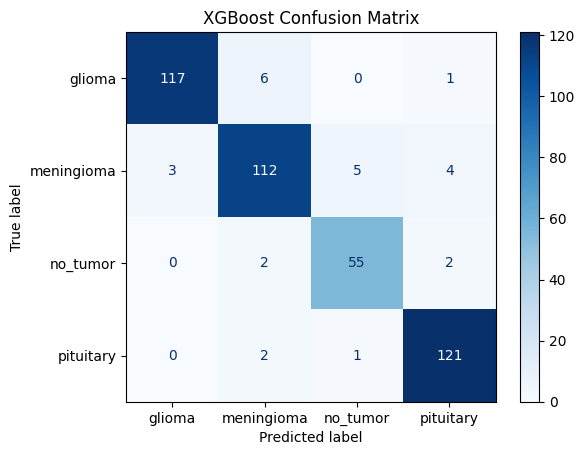

In [61]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_test_pred = xgb_model.predict(X_test)

print(classification_report(
    y_test,
    y_test_pred,
    target_names=[
        'glioma',
        'meningioma',
        'no_tumor',
        'pituitary'
    ]
))

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        'glioma',
        'meningioma',
        'no_tumor',
        'pituitary'
    ]
)

disp.plot(cmap='Blues')
plt.title("XGBoost Confusion Matrix")
plt.show()

In [62]:
# Get validation log loss history
results = xgb_model.evals_result()


val_logloss = results['validation_0']['mlogloss']   
# Find best round and lowest log loss
best_round = np.argmin(val_logloss)
best_logloss = np.min(val_logloss)

print(f"Best Boosting Round : {best_round}")
print(f"Lowest Validation Log Loss : {best_logloss:.6f}")

Best Boosting Round : 181
Lowest Validation Log Loss : 0.218376
